In [72]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

In [187]:
from pathlib import Path
import pandas as pd


def create_unique_pid_csv(
    input_path: str = "../data/processed/datasets/dataset_message_1to5.csv",
    output_path: str | None = None,
    keep: str = "first",
) -> str:
    """
    Create a new CSV where each row has a unique P_id by removing duplicate P_id rows.

    Args:
        input_path: Path to the input CSV.

    Returns:
        The path to the saved CSV file.
    """
    input_file = Path(input_path)

    if not input_file.exists():
        raise FileNotFoundError(f"Input file not found: {input_file}")

    if output_path is None:
        output_file = input_file.with_name(f"{input_file.stem}_unique_pid.csv")
    else:
        output_file = Path(output_path)

    df = pd.read_csv(input_file)

    if "P_id" not in df.columns:
        raise ValueError("Column 'P_id' not found in the input CSV.")

    df_unique = df.drop_duplicates(subset="P_id", keep=keep)

    df_unique.to_csv(output_file, index=False)

    print(f"Saved deduplicated file to: {output_file}")
    print(f"Original rows: {len(df)}")
    print(f"Rows after removing duplicate P_id values: {len(df_unique)}")
    print(f"Removed rows: {len(df) - len(df_unique)}")

    return str(output_file)
create_unique_pid_csv()

Saved deduplicated file to: ../data/processed/datasets/dataset_message_1to5_unique_pid.csv
Original rows: 137610
Rows after removing duplicate P_id values: 75440
Removed rows: 62170


'../data/processed/datasets/dataset_message_1to5_unique_pid.csv'

In [ ]:
def get_json(path: str):

    path = Path(path)

    if path.suffix != ".json":
        path = path.with_suffix(".json")

    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

In [112]:
df = pd.read_csv("../data/processed/datasets/F_M5.csv")

In [ ]:

posts_path =  "../data/raw/posts/postsFinal.json"
pdict = get_json(posts_path)

In [107]:
import numpy as np
import pandas as pd


def binary_entropy(p):
    """
    Binary entropy in bits.
    H(p) = -p log2 p - (1-p) log2(1-p)

    Define 0 * log(0) as 0.
    """
    p = np.asarray(p, dtype=float)

    out = np.zeros_like(p, dtype=float)
    mask = (p > 0) & (p < 1)

    out[mask] = -(p[mask] * np.log2(p[mask]) +
                  (1 - p[mask]) * np.log2(1 - p[mask]))
    return out


def measure_conditional_entropy(df):

    data = df.copy()

    # group only by P_id
    counts = (
        data.groupby(["P_id", "label"], dropna=False)
        .size()
        .unstack(fill_value=0)
    )

    # ensure both binary-label columns exist
    counts[0] = counts.get(0, 0)
    counts[1] = counts.get(1, 0)

    n0 = counts[0].to_numpy()
    n1 = counts[1].to_numpy()
    n = n0 + n1

    # p(y=1 | P_id)
    p1 = np.divide(n1, n, out=np.zeros_like(n1, dtype=float), where=n > 0)

    # entropy for each P_id group
    group_entropy = binary_entropy(p1)

    # weight by group frequency P(P_id) = n / N
    N = n.sum()
    conditional_entropy = np.sum((n / N) * group_entropy) if N > 0 else np.nan

    return {
        "conditional_entropy_bits": float(conditional_entropy),
    }

In [113]:
def evaluate_entropy_by_hashtag(df):
    results = {}
    for tag in df["hashtag"].dropna().unique():
        df_tag = df[df["hashtag"] == tag]
        results[tag] = measure_conditional_entropy(df_tag)
    return results

results_by_tag = evaluate_entropy_by_hashtag(df)
print(results_by_tag)

{'Trump': {'conditional_entropy_bits': 0.24833329116400793}, 'ICE': {'conditional_entropy_bits': 0.2800370196301958}, 'Gaza': {'conditional_entropy_bits': 0.2574562621587084}, 'Pokemon': {'conditional_entropy_bits': 0.38474282711394997}, 'AI': {'conditional_entropy_bits': 0.16728293016225265}, 'Booksky': {'conditional_entropy_bits': 0.30132096037630407}, 'BlackHistoryMonth': {'conditional_entropy_bits': 0.35450456347689163}, 'TheTraitors': {'conditional_entropy_bits': 0.14242581988228098}, 'Anime': {'conditional_entropy_bits': 0.2542162389171393}, 'Superbowl': {'conditional_entropy_bits': 0.2060367491773466}}


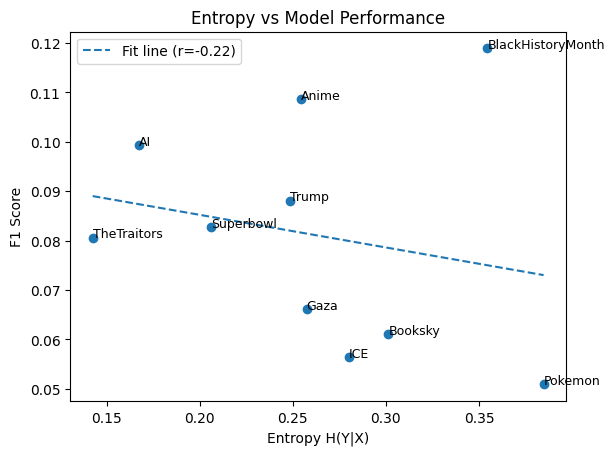

In [184]:
import numpy as np
import matplotlib.pyplot as plt

entropy = {
    "Trump": 0.24833329116400793,
    "ICE": 0.2800370196301958,
    "Gaza": 0.2574562621587084,
    "Pokemon": 0.38474282711394997,
    "AI": 0.16728293016225265,
    "Booksky": 0.30132096037630407,
    "BlackHistoryMonth": 0.35450456347689163,
    "TheTraitors": 0.14242581988228098,
    "Anime": 0.2542162389171393,
    "Superbowl": 0.2060367491773466,
}

f1 = {
    "Trump": 0.0881,
    "ICE": 0.0564,
    "Gaza": 0.0661,
    "Pokemon": 0.0509,
    "AI": 0.0993,
    "Booksky": 0.0611,
    "BlackHistoryMonth": 0.1189,
    "TheTraitors": 0.0806,
    "Anime": 0.1086,
    "Superbowl": 0.0828
}

tags = list(entropy.keys())
x = np.array([entropy[t] for t in tags])
y = np.array([f1[t] for t in tags])

plt.figure()
plt.scatter(x, y)

# annotate points
for i, tag in enumerate(tags):
    plt.text(x[i], y[i], tag, fontsize=9)

# fit and plot correlation/regression line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b
r = np.corrcoef(x, y)[0, 1]

plt.plot(x_line, y_line, linestyle='--', label=f"Fit line (r={r:.2f})")

plt.xlabel("Entropy H(Y|X)")
plt.ylabel("F1 Score")
plt.title("Entropy vs Model Performance")
plt.legend()

plt.show()

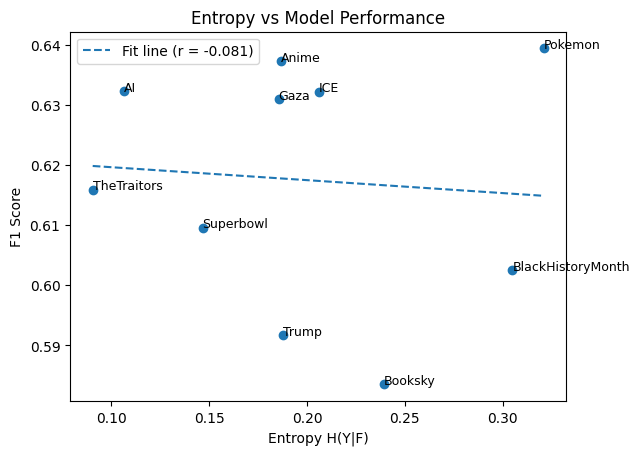

Pearson correlation: -0.0813


In [141]:
import numpy as np
import matplotlib.pyplot as plt

entropy = {
    "Trump": 0.1878931982909296,
    "ICE": 0.20604484730627262,
    "Gaza": 0.18547539889349138,
    "Pokemon": 0.3208888415709971,
    "AI": 0.1064542311533692,
    "Booksky": 0.23912572730779097,
    "BlackHistoryMonth": 0.304908806239059,
    "TheTraitors": 0.09046425654099782,
    "Anime": 0.1865601962990715,
    "Superbowl": 0.1466156720892014
}

f1 = {
    "Trump": 0.5917,
    "ICE": 0.6322,
    "Gaza": 0.6310,
    "Pokemon": 0.6394,
    "AI": 0.6323,
    "Booksky": 0.5835,
    "BlackHistoryMonth": 0.6025,
    "TheTraitors": 0.6159,
    "Anime": 0.6373,
    "Superbowl": 0.6096
}

tags = list(entropy.keys())
x = np.array([entropy[t] for t in tags])
y = np.array([f1[t] for t in tags])

# Pearson correlation
r = np.corrcoef(x, y)[0, 1]

# Best-fit line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line, linestyle="--", label=f"Fit line (r = {r:.3f})")

for i, tag in enumerate(tags):
    plt.text(x[i], y[i], tag, fontsize=9)

plt.xlabel("Entropy H(Y|F)")
plt.ylabel("F1 Score")
plt.title("Entropy vs Model Performance")
plt.legend()
plt.show()

print(f"Pearson correlation: {r:.4f}")

In [6]:
TEXTDICT = "../data/processed/text_features.json"
text_dict = get_json(TEXTDICT)

In [10]:
for k,v in text_dict["at://did:plc:26sbo73b4mqghlnzb74bb7ra/app.bsky.feed.post/3mfzwraclhs2r"].items():
    print(k,v)

text_len 65
word_count 14
neg 0.0
neu 1.0
pos 0.0
compound 0.0
sentiment_overall 0
grammar-word-score 1.0
grammar-sentence-score 1.0
subjectivity 0.0
polarity 0.0
emo_overall 0
emo_anger 0.003987029194831848
emo_joy 0.005671617574989796
emo_fear 0.004945153370499611
emo_disgust 0.10876777768135071
emo_surprise 0.0023337160237133503
emo_sadness 0.0047761243768036366
emo_others 0.8695186376571655
hs_aggressive 0.011227115988731384
hs_hateful 0.019834667444229126
hs_targeted 0.010089662857353687
hs_count 0
irony 1
offensive 0.17678003013134003
emoji 2
Kincaid 5.041428571428572
ARI 3.0642857142857167
Coleman-Liau 3.9252654285714286
FleschReadingEase 83.85357142857144
GunningFogIndex 8.457142857142857
LIX 35.42857142857143
SMOGIndex 8.477225575051662
RIX 3.0
DaleChallIndex 2.9501142857142857
complex_words 1.0
complex_words_dc 2.0
arts_&_culture 0.011225258931517601
business_&_entrepreneurs 0.004843094851821661
celebrity_&_pop_culture 0.0258044321089983
diaries_&_daily_life 0.127693176269531

In [21]:
import csv
from langdetect import detect, LangDetectException

def build_text_csv_trump(posts: dict, output_file="test.csv"):
    """
    Write {post_uri, text} to a CSV file
    ONLY for posts where hashtag == 'Trump'
    and the text is detected as English.
    Also prints the number of posts written.
    """
    seen = set()
    count = 0

    with open(output_file, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["post_uri", "full_text"])

        for uri, post in posts.items():
            if post.get("hashtag") != "Trump":
                continue

            text = post.get("record", {}).get("text")
            if not (uri and text and uri not in seen):
                continue

            try:
                if detect(str(text)) != "en":
                    continue
            except LangDetectException:
                continue

            writer.writerow([uri, str(text)])
            seen.add(uri)
            count += 1

    print(f"Number of posts written: {count}")

build_text_csv_trump(pdict)

Number of posts written: 8915


In [180]:
d = "dataset_bert_1to5.csv"

In [183]:
import pandas as pd


def print_label_counts_by_hashtag(csv_path, hashtag_col="hashtag", label_col="label"):
    df = pd.read_csv(csv_path)

    if hashtag_col not in df.columns:
        raise ValueError(f"Column '{hashtag_col}' not found in {csv_path}")
    if label_col not in df.columns:
        raise ValueError(f"Column '{label_col}' not found in {csv_path}")

    for hashtag, group in df.groupby(hashtag_col):
        num_ones = (group[label_col] == 1).sum()
        num_zeroes = (group[label_col] == 0).sum()
        ratio = num_ones / len(group) if len(group) > 0 else 0.0

        print(f"Hashtag: {hashtag}")
        print(f"  Ones: {num_ones}")
        print(f"  Zeroes: {num_zeroes}")
        print(f"  Total: {len(group)}")
        print(f"  Ratio of ones: {ratio:.4f}")
        print()


print_label_counts_by_hashtag(f"../data/processed/datasets/{d}")

Hashtag: AI
  Ones: 1259
  Zeroes: 6295
  Total: 7554
  Ratio of ones: 0.1667

Hashtag: Anime
  Ones: 2124
  Zeroes: 10620
  Total: 12744
  Ratio of ones: 0.1667

Hashtag: BlackHistoryMonth
  Ones: 3578
  Zeroes: 17890
  Total: 21468
  Ratio of ones: 0.1667

Hashtag: Booksky
  Ones: 2752
  Zeroes: 13760
  Total: 16512
  Ratio of ones: 0.1667

Hashtag: Gaza
  Ones: 2176
  Zeroes: 10880
  Total: 13056
  Ratio of ones: 0.1667

Hashtag: ICE
  Ones: 2466
  Zeroes: 12330
  Total: 14796
  Ratio of ones: 0.1667

Hashtag: Pokemon
  Ones: 3667
  Zeroes: 18335
  Total: 22002
  Ratio of ones: 0.1667

Hashtag: Superbowl
  Ones: 1726
  Zeroes: 8630
  Total: 10356
  Ratio of ones: 0.1667

Hashtag: TheTraitors
  Ones: 1071
  Zeroes: 5355
  Total: 6426
  Ratio of ones: 0.1667

Hashtag: Trump
  Ones: 2090
  Zeroes: 10450
  Total: 12540
  Ratio of ones: 0.1667



In [182]:
import pandas as pd


def enforce_exact_label_ratio_from_csv(
    neg_per_pos: int,
    csv_path: str = f"../data/processed/datasets/{d}",
    hashtag_col: str = "hashtag",
    label_col: str = "label",
    save_path: str = f"../data/processed/datasets/{d}",
    random_state: int = 42,
) -> pd.DataFrame:
    """
    For each hashtag, enforce the exact ratio:
        positives : negatives = 1 : neg_per_pos

    This is done by randomly removing either negatives or positives.

    Example:
        neg_per_pos=1 -> 1:1
        neg_per_pos=5 -> 1:5
    """
    df = pd.read_csv(csv_path)

    kept_parts = []

    for _, group in df.groupby(hashtag_col, sort=False):
        positives = group[group[label_col] == 1]
        negatives = group[group[label_col] == 0]

        n_pos = len(positives)
        n_neg = len(negatives)

        if n_pos == 0 or n_neg == 0:
            continue

        # Largest feasible exact ratio subset
        keep_pos = min(n_pos, n_neg // neg_per_pos)
        keep_neg = keep_pos * neg_per_pos

        if keep_pos == 0 or keep_neg == 0:
            continue

        positives = positives.sample(n=keep_pos, random_state=random_state)
        negatives = negatives.sample(n=keep_neg, random_state=random_state)

        balanced_group = pd.concat([positives, negatives]).sort_index()
        kept_parts.append(balanced_group)

    if not kept_parts:
        result = pd.DataFrame(columns=df.columns)
    else:
        result = pd.concat(kept_parts).sort_index().reset_index(drop=True)

    result.to_csv(save_path, index=False)
    return result
enforce_exact_label_ratio_from_csv(neg_per_pos=5)

,A_id,S_id,P_id,hashtag,text,label
0,did:plc:rgn3wjhjtfbtaf55ewqbjb4j,did:plc:pwo2tzlabqaxzbwrx65pzsk3,at://did:plc:pwo2tzlabqaxzbwrx65pzsk3/app.bsky...,Trump,Trump tries to bomb Iran into regime change wh...,1
1,did:plc:uzwlpibth4vcttpqrw5hhfrx,did:plc:gtqybdeowyge7ycnt75jre5w,at://did:plc:gtqybdeowyge7ycnt75jre5w/app.bsky...,Trump,Trump's video statement on the ongoing attacks...,0
2,did:plc:y7qhktweludzdbdcjuocheyu,did:plc:qjd6m5tlkbwulpvntzjbfjux,at://did:plc:qjd6m5tlkbwulpvntzjbfjux/app.bsky...,Trump,Venezuela holds the world's largest proven oil...,0
3,did:plc:4x6his3y4ycgxrjkb2vqvsqg,did:plc:fgiqkkrmaycusjocndaqrpz3,at://did:plc:fgiqkkrmaycusjocndaqrpz3/app.bsky...,Trump,Revealed: Where #Epstein files could be hiding...,0
4,did:plc:gdg3slu366jwtvopjiujpplr,did:plc:tqma3outiazw5tx4vo7yjb4d,at://did:plc:tqma3outiazw5tx4vo7yjb4d/app.bsky...,Trump,Starmer says that UK air bases are not to be u...,1
...,...,...,...,...,...,...
137449,did:plc:ne5ub6pgzqoikjnn4uzi7jd3,did:plc:lc6hdhnjkgccd6ysi7e23pll,at://did:plc:lc6hdhnjkgccd6ysi7e23pll/app.bsky...,AI,"As the price of intelligence collapses, agenti...",0
137450,did:plc:2iewny6fy6tf53t3rfr5ansx,did:plc:rmqahs4r3ogkejvkixv37epu,at://did:plc:rmqahs4r3ogkejvkixv37epu/app.bsky...,AI,What I’m saying is that #AI is opening opportu...,0
137451,did:plc:ista4a5pfvvml6tgtosvvx5f,did:plc:m5dcinlrpxq6rm2uficksxp7,at://did:plc:m5dcinlrpxq6rm2uficksxp7/app.bsky...,AI,"Widelands, the open source Settlers-like devs ...",1
137452,did:plc:pkskikvaijwl3m7gw2qywext,did:plc:qtemixyzug47kayx73doktyv,at://did:plc:qtemixyzug47kayx73doktyv/app.bsky...,AI,This economic idea transfixed Wall Street and ...,0


In [13]:
import pandas as pd
import numpy as np

def hashtag_overlap_matrix(df, hashtag_col="hashtag", user_col="A_id"):
    # Build hashtag -> set of unique users
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.expand_frame_repr", False)
    hashtag_users = (
        df.groupby(hashtag_col)[user_col]
        .apply(lambda x: set(x.unique()))
        .to_dict()
    )
    
    hashtags = sorted(hashtag_users.keys())
    
    # Print unique recipient counts
    print("Pairwise overlap matrix (1:1)")

    # Initialize zero matrix
    n = len(hashtags)
    overlap_matrix = pd.DataFrame(
        np.zeros((n, n), dtype=int),
        index=hashtags,
        columns=hashtags
    )
    
    # Fill diagonal + upper triangle only
    for i, tag1 in enumerate(hashtags):
        users1 = hashtag_users[tag1]
        overlap_matrix.iloc[i, i] = len(users1)  # diagonal
        
        for j in range(i + 1, n):
            tag2 = hashtags[j]
            users2 = hashtag_users[tag2]
            overlap = len(users1 & users2)
            overlap_matrix.iloc[i, j] = overlap
    
    return overlap_matrix
matrix = hashtag_overlap_matrix(df)
print(matrix)

Pairwise overlap matrix (1:1)
                     AI  Anime  BlackHistoryMonth  Booksky  Gaza   ICE  Pokemon  Superbowl  TheTraitors  Trump
AI                 4441    182                235      127   301   517       36        222           20    439
Anime                 0   5365                177      111    38    60      484         84            7     34
BlackHistoryMonth     0      0               8210      375   411   843      165        527           31    591
Booksky               0      0                  0     5613   106   210       85        183           33    151
Gaza                  0      0                  0        0  4349   762       32        250           41    736
ICE                   0      0                  0        0     0  6158       49        525           31   1262
Pokemon               0      0                  0        0     0     0     9591        115           29     15
Superbowl             0      0                  0        0     0     0        0   

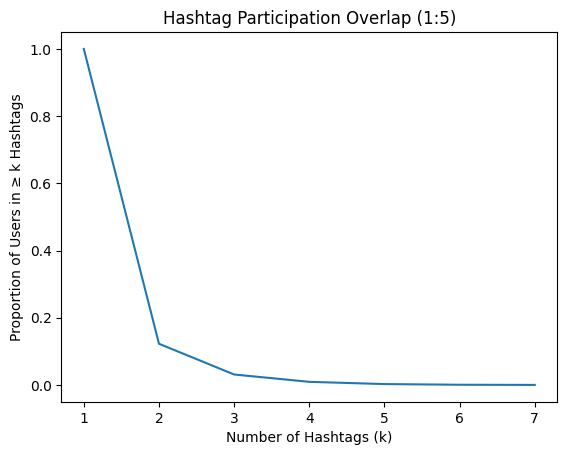

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hashtag_participation(df, hashtag_col="hashtag", user_col="A_id"):
    
    # Count unique hashtags per user
    user_hashtag_counts = (
        df.groupby(user_col)[hashtag_col]
          .nunique()
    )
    
    total_users = len(user_hashtag_counts)
    max_k = user_hashtag_counts.max()
    
    k_values = list(range(1, max_k + 1))
    proportions = [
        (user_hashtag_counts >= k).sum() / total_users
        for k in k_values
    ]
    
    plt.figure()
    plt.plot(k_values, proportions)
    
    # 👇 Force all integer ticks to show
    plt.xticks(k_values)
    
    plt.xlabel("Number of Hashtags (k)")
    plt.ylabel("Proportion of Users in ≥ k Hashtags")
    plt.title("Hashtag Participation Overlap (1:5)")
    plt.show()


# Run
plot_hashtag_participation(df)

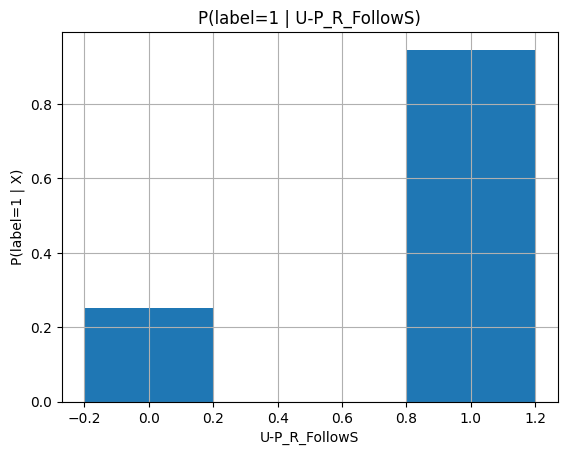

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_label_given_x(df, column, bins=50, x_max=None, title=None):
    """
    Plots P(label=1 | X).
    Handles both continuous and binary features.
    """

    x = df[column].values
    y = df["label"].values

    # Optional clipping
    if x_max is not None:
        mask = x <= x_max
        x = x[mask]
        y = y[mask]

    unique_vals = np.unique(x)

    # ------------------------------
    # Binary feature case
    # ------------------------------
    if len(unique_vals) <= 2:

        xs = []
        ps = []

        for val in sorted(unique_vals):
            mask = x == val
            if np.sum(mask) > 0:
                xs.append(val)
                ps.append(np.mean(y[mask]))

        plt.figure()
        plt.bar(xs, ps, width=0.4)

    # ------------------------------
    # Continuous feature case
    # ------------------------------
    else:

        bin_edges = np.linspace(np.min(x), np.max(x), bins + 1)
        bin_indices = np.digitize(x, bin_edges) - 1

        prob = []
        bin_centers = []

        for i in range(bins):
            mask = bin_indices == i
            if np.sum(mask) > 0:
                p = np.mean(y[mask])
                prob.append(p)
                bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)

        plt.figure()
        plt.plot(bin_centers, prob)

    plt.xlabel(column)
    plt.ylabel("P(label=1 | X)")

    if title:
        plt.title(title)
    else:
        plt.title(f"P(label=1 | {column})")

    plt.grid(True)
    plt.show()
plot_p_label_given_x(df, "U-P_R_FollowS")

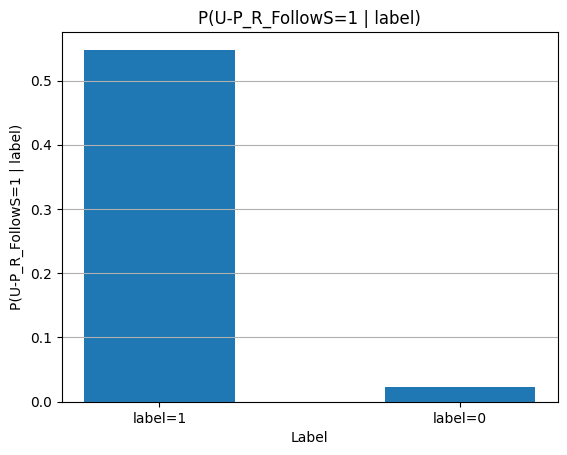

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_x_given_label(df, column, title=None):
    """
    Plots P(X=1 | label).
    Assumes the column is binary (0/1).
    """

    x = df[column].values
    y = df["label"].values

    p_x1_given_label1 = np.mean(x[y == 1])
    p_x1_given_label0 = np.mean(x[y == 0])

    xs = ["label=1", "label=0"]
    ps = [p_x1_given_label1, p_x1_given_label0]

    plt.figure()
    plt.bar(xs, ps, width=0.5)

    plt.ylabel(f"P({column}=1 | label )")
    plt.xlabel("Label")

    if title:
        plt.title(title)
    else:
        plt.title(f"P({column}=1 | label )")

    plt.grid(axis="y")
    plt.show()
plot_p_x_given_label(df,"U-P_R_FollowS")

In [15]:
from collections import defaultdict

def count_zero_vs_nonzero_reposts_by_hashtag(posts: dict) -> dict:
    """
    Count, for each hashtag:
      - how many posts have 0 reposts
      - how many posts have 1+ reposts

    Returns:
        {
            "hashtag1": {"zero_reposts": ..., "nonzero_reposts": ..., "total_posts": ...},
            ...
        }
    """
    counts = defaultdict(lambda: {
        "zero_reposts": 0,
        "nonzero_reposts": 0,
        "total_posts": 0,
    })

    for _, post in posts.items():
        hashtag = post.get("hashtag")
        if not hashtag:
            continue

        reposts = post.get("stored_reposters") or []

        counts[hashtag]["total_posts"] += 1

        if len(reposts) == 0:
            counts[hashtag]["zero_reposts"] += 1
        else:
            counts[hashtag]["nonzero_reposts"] += 1

    return dict(counts)
stats = count_zero_vs_nonzero_reposts_by_hashtag(pdict)

for hashtag, values in stats.items():
    print(hashtag, values)

Trump {'zero_reposts': 7640, 'nonzero_reposts': 2615, 'total_posts': 10255}
ICE {'zero_reposts': 8019, 'nonzero_reposts': 2968, 'total_posts': 10987}
AI {'zero_reposts': 8614, 'nonzero_reposts': 2386, 'total_posts': 11000}
Gaza {'zero_reposts': 7151, 'nonzero_reposts': 3822, 'total_posts': 10973}
Pokemon {'zero_reposts': 6891, 'nonzero_reposts': 4098, 'total_posts': 10989}
BlackHistoryMonth {'zero_reposts': 6158, 'nonzero_reposts': 4777, 'total_posts': 10935}
Booksky {'zero_reposts': 7171, 'nonzero_reposts': 3764, 'total_posts': 10935}
Superbowl {'zero_reposts': 9058, 'nonzero_reposts': 1901, 'total_posts': 10959}
TheTraitors {'zero_reposts': 9639, 'nonzero_reposts': 1361, 'total_posts': 11000}
Anime {'zero_reposts': 6216, 'nonzero_reposts': 4481, 'total_posts': 10697}


In [16]:
from collections import defaultdict

def count_zero_vs_nonzero_reposts_by_hashtag(posts: dict) -> dict:
    """
    Count, for each hashtag:
      - how many posts have repostCount == 0
      - how many posts have repostCount > 0

    Returns:
        {
            "hashtag1": {
                "zero_reposts": int,
                "nonzero_reposts": int,
                "total_posts": int,
            },
            ...
        }
    """
    counts = defaultdict(lambda: {
        "zero_reposts": 0,
        "nonzero_reposts": 0,
        "total_posts": 0,
    })

    for _, post in posts.items():
        hashtag = post.get("hashtag")
        if not hashtag:
            continue

        repost_count = post.get("repostCount", 0) or 0

        counts[hashtag]["total_posts"] += 1

        if repost_count == 0:
            counts[hashtag]["zero_reposts"] += 1
        else:
            counts[hashtag]["nonzero_reposts"] += 1

    return dict(counts)
stats = count_zero_vs_nonzero_reposts_by_hashtag(pdict)

for hashtag, values in stats.items():
    print(hashtag, values)

Trump {'zero_reposts': 7608, 'nonzero_reposts': 2647, 'total_posts': 10255}
ICE {'zero_reposts': 7986, 'nonzero_reposts': 3001, 'total_posts': 10987}
AI {'zero_reposts': 8553, 'nonzero_reposts': 2447, 'total_posts': 11000}
Gaza {'zero_reposts': 7071, 'nonzero_reposts': 3902, 'total_posts': 10973}
Pokemon {'zero_reposts': 6873, 'nonzero_reposts': 4116, 'total_posts': 10989}
BlackHistoryMonth {'zero_reposts': 6076, 'nonzero_reposts': 4859, 'total_posts': 10935}
Booksky {'zero_reposts': 7117, 'nonzero_reposts': 3818, 'total_posts': 10935}
Superbowl {'zero_reposts': 8219, 'nonzero_reposts': 2740, 'total_posts': 10959}
TheTraitors {'zero_reposts': 9615, 'nonzero_reposts': 1385, 'total_posts': 11000}
Anime {'zero_reposts': 6009, 'nonzero_reposts': 4688, 'total_posts': 10697}
